# 00.1 — Environment Verification

**Phase:** 00 — Environment Setup

**Difficulty:** 🟢 Beginner | **Priority:** Essential

---

## 1. What Are We Solving?

Before writing any ML code, we need a **working, verified, reproducible environment**. This means:

1. Python is installed and the right version is running.
2. All required packages are installed and importable.
3. GPU availability is known (or CPU-only mode is confirmed).
4. Internet access works for downloading datasets and using APIs.
5. The full ML stack actually produces correct results.

If any of these are broken, every error you see later becomes ambiguous: **is the code wrong, or is the setup wrong?**

## 2. Why Does This Matter?

In real projects, environment problems waste enormous time. A missing package, wrong Python version, or unactivated virtual environment causes confusing errors that look like code bugs. This notebook catches all of that **before** you start learning.

### Mental Model: The Environment as a Workshop

```text
Operating System (Windows/Linux/Mac)
    ↓
Python interpreter (3.13+)
    ↓
Virtual environment (.venv — isolated toolbox for this project)
    ↓
Packages (NumPy, Pandas, PyTorch, etc.)
    ↓
Notebook kernel (connects notebook cells to the interpreter)
    ↓
Git history (tracks changes so you can recover from mistakes)
```

If one layer is wrong, code may fail even when the logic is correct.

## 3. Prerequisites

- Python 3.13+ installed
- A virtual environment created and activated
- Packages installed (see `pyproject.toml` or `requirements.txt`)

## 4. Learning Objectives

By the end of this notebook, you should be able to:

- [ ] Verify your Python version and interpreter path
- [ ] Verify all required packages are installed
- [ ] Check GPU availability
- [ ] Check internet connectivity
- [ ] Run a sanity check proving the full stack works
- [ ] Diagnose and fix common environment problems
- [ ] Explain why environment verification matters

## 5. Verify Python and System Info

The first thing to check: **which Python is running, and where is it?**

This matters because:
- You might have multiple Python versions installed.
- Your notebook kernel might use a different Python than your terminal.
- Packages installed in one environment are invisible to another.

**Key signal:** `sys.executable` should point to your project's `.venv`, not a system Python.

In [1]:
import sys
import platform
import os

print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")
print(f"Platform: {platform.platform()}")
print(f"Machine: {platform.machine()}")
print(f"Processor: {platform.processor()}")
print(f"Current working directory: {os.getcwd()}")

# Check if we're in a virtual environment
in_venv = hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix)
print(f"\nVirtual environment active: {in_venv}")
if in_venv:
    print(f"  venv prefix: {sys.prefix}")
else:
    print(f"  WARNING: No virtual environment detected. Packages may install globally.")
    print(f"  Fix: activate your .venv before running this notebook.")

Python version: 3.13.9 (main, Oct 31 2025, 22:58:20) [MSC v.1944 64 bit (AMD64)]
Python executable: D:\CODE\complete ml\.venv\Scripts\python.exe
Platform: Windows-11-10.0.26100-SP0
Machine: AMD64
Processor: Intel64 Family 6 Model 61 Stepping 4, GenuineIntel
Current working directory: D:\CODE\complete ml\notebooks\00_environment

Virtual environment active: True
  venv prefix: D:\CODE\complete ml\.venv


### What to look for

| Check | Good | Bad |
|---|---|---|
| Python version | 3.13+ | 3.9 or older |
| Executable path | Contains `.venv` or project name | `C:\Python313\python.exe` (system) |
| Virtual env | `True` | `False` |

If the executable points to a system Python, your packages may install globally and conflict with other projects.

## 6. Verify Core Packages

These are the packages used in every ML/data project:

| Package | Purpose |
|---|---|
| `numpy` | Numerical arrays and vectorized math |
| `pandas` | Tabular data manipulation |
| `scipy` | Scientific computing and statistics |
| `sklearn` | Classical machine learning |
| `matplotlib` | Plotting and visualization |
| `seaborn` | Statistical visualization (built on matplotlib) |
| `plotly` | Interactive visualization |

**Why these matter:** If any are missing, you cannot load data, plot results, or train models.

In [2]:
import importlib

core_packages = {
    "numpy": "2.0",
    "pandas": "2.0",
    "scipy": "1.10",
    "sklearn": "1.3",
    "matplotlib": "3.7",
    "seaborn": "0.13",
    "plotly": "5.0",
}

print("=== Core Packages ===")
all_ok = True
for pkg, min_ver in core_packages.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        status = "OK" if ver != "unknown" else "OK (no version)"
        print(f"  {pkg:15s} {ver:12s} {status}")
    except ImportError as e:
        print(f"  {pkg:15s} MISSING  {e}")
        all_ok = False

print(f"\nCore packages: {'ALL OK' if all_ok else 'SOME MISSING'}")
if not all_ok:
    print("Fix: uv add <package_name> or pip install <package_name>")

=== Core Packages ===


  numpy           2.5.2        OK


  pandas          3.0.5        OK


  scipy           1.18.1       OK


  sklearn         1.9.0        OK


  matplotlib      3.11.1       OK


  seaborn         0.13.2       OK


  plotly          7.0.0        OK

Core packages: ALL OK


## 7. Verify Deep Learning Packages

These are used in Phase 06+ for neural networks:

| Package | Purpose |
|---|---|
| `torch` | PyTorch — deep learning framework |
| `transformers` | Hugging Face — pretrained models |
| `datasets` | Hugging Face — dataset loading |
| `tokenizers` | Fast tokenization for NLP |
| `accelerate` | Multi-GPU/distributed training |
| `sentence_transformers` | Text embeddings |

**Note:** These are heavy packages. If install fails, it is usually a disk space or network issue.

In [3]:
dl_packages = ["torch", "transformers", "datasets", "tokenizers", "accelerate", "sentence_transformers"]

print("=== Deep Learning Packages ===")
for pkg in dl_packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg:20s} {ver}")
    except ImportError as e:
        print(f"  {pkg:20s} MISSING  {e}")

=== Deep Learning Packages ===


  torch                2.13.0+cpu


D:\CODE\complete ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  transformers         5.16.1


  datasets             5.0.1


  tokenizers           0.23.1


  accelerate           1.14.0


  sentence_transformers 6.0.0


## 8. Verify ML / LLM Packages

These are used in Phases 09–16 for LLMs, RAG, and deployment:

| Package | Purpose |
|---|---|
| `xgboost`, `lightgbm` | Gradient boosting (tabular ML) |
| `langchain`, `langchain_openai` | LLM framework abstractions |
| `langgraph` | Stateful LLM workflows |
| `openai` | OpenAI API client |
| `tiktoken` | Token counting |
| `faiss` | Vector similarity search |
| `chromadb` | Vector database |

In [4]:
ml_packages = ["xgboost", "lightgbm", "langchain", "langchain_openai", "langgraph", "openai", "tiktoken", "faiss", "chromadb"]

print("=== ML / LLM Packages ===")
for pkg in ml_packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg:20s} {ver}")
    except ImportError as e:
        print(f"  {pkg:20s} MISSING  {e}")

=== ML / LLM Packages ===


  xgboost              3.4.1


  lightgbm             4.7.0
  langchain            1.3.18


  langchain_openai     1.6.0
  langgraph            unknown
  openai               3.5.0
  tiktoken             0.14.0


  faiss                1.15.0


  chromadb             1.5.9


## 9. Verify Web / Utility Packages

These support API building, data collection, and configuration:

| Package | Purpose |
|---|---|
| `fastapi`, `uvicorn` | API server and ASGI runner |
| `flask` | Lightweight web framework |
| `requests` | HTTP client |
| `bs4` (BeautifulSoup) | HTML parsing |
| `pymupdf`, `pypdf` | PDF reading |
| `pydantic` | Data validation |
| `kagglehub` | Kaggle dataset download |

**Note:** Some packages like `openduplicates` may fail due to Python version incompatibility. That is usually non-critical.

In [5]:
util_packages = ["fastapi", "uvicorn", "flask", "requests", "bs4", "pymupdf", "pypdf", "dotenv", "pydantic", "kagglehub", "opendatasets"]

print("=== Web / Utility Packages ===")
for pkg in util_packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg:20s} {ver}")
    except ImportError as e:
        print(f"  {pkg:20s} MISSING  {e}")

=== Web / Utility Packages ===


  fastapi              0.141.1


  uvicorn              0.52.4


C:\Users\PC\AppData\Local\Temp\ipykernel_7628\809325106.py:7: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  ver = getattr(mod, "__version__", "unknown")


  flask                3.1.3
  requests             2.34.2


  bs4                  4.15.0


  pymupdf              1.28.2


  pypdf                6.16.2
  dotenv               unknown
  pydantic             2.13.5


  kagglehub            1.0.2
  opendatasets         MISSING  No module named 'cgi'


## 10. Check GPU Availability

This curriculum works on CPU, but a GPU speeds up deep learning by 10–100x.

### What happens on GPU vs CPU?

| Aspect | CPU | GPU |
|---|---|---|
| Speed (DL training) | Slow (hours/days) | Fast (minutes/hours) |
| Speed (small models) | Fine | Fine |
| Memory | Shared with system | Dedicated VRAM |
| Cost | Free | Hardware or cloud cost |

**No GPU?** That is perfectly fine for this curriculum. All code will run on CPU — it will just be slower for deep learning training.

In [6]:
try:
    import torch
    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")
    if cuda_available:
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU count: {torch.cuda.device_count()}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
    else:
        print("No GPU detected. Using CPU (works fine for this curriculum).")
except ImportError:
    print("PyTorch not installed. Cannot check GPU.")

CUDA available: False
No GPU detected. Using CPU (works fine for this curriculum).


## 11. Check Internet Connectivity

Internet is needed for:
- Downloading datasets (Hugging Face, Kaggle)
- Using LLM APIs (OpenAI, Anthropic, Google)
- Installing packages
- Downloading pretrained models

If internet fails, you can still work with local data and local models.

In [7]:
import requests

try:
    r = requests.get("https://www.google.com", timeout=5)
    print(f"Internet: OK (status {r.status_code})")
except Exception as e:
    print(f"Internet: FAILED ({e})")
    print("Note: Some features (dataset download, API calls) will not work without internet.")

Internet: OK (status 200)


## 12. Quick Sanity Check

Let's verify the core stack actually works with a tiny computation. This is not just import checking — it is **proving that the stack produces correct results**.

We will:
1. Create synthetic data with NumPy
2. Fit a linear regression with scikit-learn
3. Plot the result with Matplotlib

If this runs without errors and the learned parameters are close to the true parameters, the environment is verified.

True slope: 2.0, True intercept: 3.0
Learned slope: 1.977, Learned intercept: 3.108


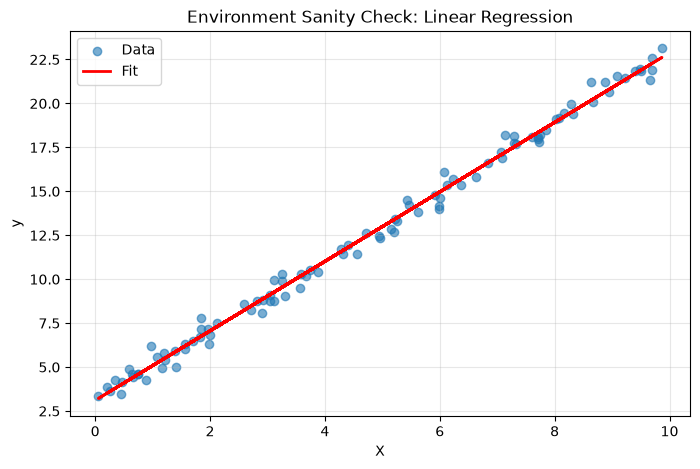


Sanity check: PASSED — the full stack works!


In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create a tiny dataset with known parameters
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + 3 + np.random.randn(100) * 0.5

# Fit a model
model = LinearRegression()
model.fit(X, y)

print(f"True slope: 2.0, True intercept: 3.0")
print(f"Learned slope: {model.coef_[0]:.3f}, Learned intercept: {model.intercept_:.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Environment Sanity Check: Linear Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nSanity check: PASSED — the full stack works!")

## 13. Troubleshooting Guide

If something fails, use this table to diagnose:

| Symptom | Possible Cause | How to Verify | How to Fix |
|---|---|---|---|
| `ModuleNotFoundError` | Package not installed in this environment | Check `sys.executable` | Install using the same interpreter: `python -m pip install <pkg>` |
| Notebook cannot find a file | Wrong working directory | Print `os.getcwd()` | Use project-relative paths, not absolute paths |
| GPU not detected | Missing CUDA driver or CPU-only PyTorch | Check `torch.version.cuda` | Use CPU for now; GPU setup is optional |
| Internet fails | Firewall, proxy, or no connection | Check `requests.get()` | Work offline; datasets can be cached locally |
| Package version conflict | Incompatible versions | Check `pip list` or `uv pip list` | Use `pyproject.toml` to pin compatible versions |
| `Jupyter kernel not found` | IPyKernel not installed | Check kernel list | `python -m ipykernel install --user` |
| Slow import / hang | Large package (PyTorch, transformers) | Wait; first import is slow | Normal — subsequent imports are faster |

## 14. Common Mistakes

1. **Using the wrong Python**: your kernel should use the `.venv` Python (`sys.executable`), not a system Python.

2. **Installing globally instead of in the venv**: if `pip install` succeeds but the notebook still says `MISSING`, you installed into the wrong environment.

3. **Not restarting the kernel after install**: if you install a package mid-session, restart the kernel and re-run all cells.

4. **Ignoring warnings**: warnings often signal version mismatches that become errors later.

5. **Assuming imports work without testing**: always verify imports at the start of a notebook.

## 15. What This Environment Prepares For

This verified environment is the foundation for every phase that follows:

| Phase | Uses From This Environment |
|---|---|
| Phase 01 (Python) | All core packages |
| Phase 02 (Math) | NumPy, Matplotlib |
| Phase 03 (Statistics) | NumPy, Pandas, Matplotlib, SciPy |
| Phase 04 (Data) | Pandas, Matplotlib, Seaborn |
| Phase 05 (ML) | scikit-learn, XGBoost, LightGBM |
| Phase 06 (Deep Learning) | PyTorch, GPU |
| Phase 07–08 (NLP/Transformers) | Transformers, Tokenizers |
| Phase 09–11 (GenAI/LLMs/RAG) | OpenAI, LangChain, FAISS, ChromaDB |
| Phase 12–14 (Frameworks/Agents) | LangChain, LangGraph |
| Phase 16 (Deployment) | FastAPI, Uvicorn, Docker |

Every future notebook in this curriculum assumes this environment works.

## 16. Hands-On Practice

### Exercise 1 — Basic
Print your Python version and `sys.executable`. Confirm the path contains `.venv`.

### Exercise 2 — Guided
Write a function that checks if a package is installed and prints its version. Test it on 3 packages.

### Exercise 3 — Independent
Write a script that checks ALL packages at once and produces a summary table: package name, version, status (OK/MISSING).

### Exercise 4 — Realistic
Intentionally break something (e.g., change the import name to a wrong package) and observe the error. Fix it. This teaches you to recognize the error pattern.

### Exercise 5 — Challenge
Write a `check_environment()` function that returns a dictionary with all checks (Python version, packages, GPU, internet) and a overall pass/fail status. Use it to produce a one-line environment report.

In [9]:
# Exercise 5 — Your environment report function
# Write your check_environment() function here

def check_environment():
    """Return a dictionary with environment status."""
    report = {}

    # Python version
    report["python_version"] = sys.version.split()[0]

    # Key packages
    key_packages = ["numpy", "pandas", "sklearn", "matplotlib", "torch"]
    report["packages"] = {}
    for pkg in key_packages:
        try:
            mod = importlib.import_module(pkg)
            report["packages"][pkg] = getattr(mod, "__version__", "installed")
        except ImportError:
            report["packages"][pkg] = "MISSING"

    # GPU
    try:
        import torch
        report["gpu"] = torch.cuda.is_available()
    except ImportError:
        report["gpu"] = "unknown"

    # Internet
    try:
        requests.get("https://www.google.com", timeout=3)
        report["internet"] = True
    except Exception:
        report["internet"] = False

    # Overall
    missing = [k for k, v in report["packages"].items() if v == "MISSING"]
    report["status"] = "PASS" if not missing else f"FAIL: missing {missing}"

    return report

# Run it
report = check_environment()
print(f"Python: {report['python_version']}")
print(f"GPU: {report['gpu']}")
print(f"Internet: {report['internet']}")
print(f"Status: {report['status']}")
print(f"\nPackages:")
for pkg, ver in report["packages"].items():
    print(f"  {pkg:12s} {ver}")

Python: 3.13.9
GPU: False
Internet: True
Status: PASS

Packages:
  numpy        2.5.2
  pandas       3.0.5
  sklearn      1.9.0
  matplotlib   3.11.1
  torch        2.13.0+cpu


## 17. Teach-Back Questions

Before moving on, answer these without looking at the notebook:

1. **Why do Python projects use virtual environments?**

2. **What does `sys.executable` tell you, and why does it matter?**

3. **If `import numpy` works in a terminal but not in a notebook, what is the most likely cause?**

4. **What is the difference between a code bug and an environment bug?**

5. **Why does this notebook check packages in groups (core, DL, ML/LLM, utility)?**

6. **What would happen if you installed PyTorch with CUDA support but had no GPU?**

## 18. Exit Criteria

You are ready to move to the next unit when you can:

- [ ] Verify Python version and interpreter path
- [ ] Verify key packages are installed
- [ ] Check GPU availability
- [ ] Check internet connectivity
- [ ] Run a sanity check proving the full stack works
- [ ] Diagnose `ModuleNotFoundError` and fix it
- [ ] Explain the difference between system Python and venv Python
- [ ] Explain why environment verification prevents future debugging pain

## 19. Next Step

This notebook verified that your environment works. The next notebook (`00_02_jupyter_workflow.ipynb`) teaches you to use Jupyter effectively — cells, kernels, markdown, execution order, and "Restart & Run All".

---

## 20. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: PASS
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```